# COMP3010 Assignment — BLEVE Peak Pressure Prediction
**Student Name:** Mohammed Ishtiaq
**Kaggle Team Name:** 22856133
**Final Public Leaderboard Score:** 0.17849

**Models evaluated:** ElasticNet · SVR · XGBoost · Neural Network (MLP)  
**Final model:** Ensemble (XGBoost + Neural Network)


## 1. Install & Import

In [ ]:
# Install XGBoost if not already available
!pip install xgboost -q

import warnings, copy
warnings.filterwarnings('ignore')

# Core data manipulation and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities for cross-validation, preprocessing, and metrics
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_percentage_error, r2_score,
                             mean_squared_error, mean_absolute_error)
# Gradient boosting model
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Global settings — fixed seed for reproducibility across all models
SEED = 42
NFOLDS = 5
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available, otherwise fallback to CPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('XGBoost:', xgb.__version__, '| PyTorch:', torch.__version__, '| Device:', DEVICE)


XGBoost: 3.2.0 | PyTorch: 2.10.0+cpu | Device: cpu


## 2. Load Data
Load training and test datasets, drop unnamed index columns, and standardise column names.

In [2]:
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

# Drop unnamed index column if present
for df in [train_raw, test_raw]:
    df.drop(columns=[c for c in df.columns if 'Unnamed' in c], inplace=True, errors='ignore')

# ── Standardise column names ──────────────────────────────────────────────
# The dataset uses 'Liquid Ratio (%)' — rename to 'Liquid Ratio' for clarity
RENAME = {
    'Liquid Ratio (%)':              'Liquid Ratio',
    'Liquid Boiling Temperature (K)': 'Liquid Boiling Temperature (K)',  # already OK
}
train_raw.rename(columns=RENAME, inplace=True)
test_raw.rename(columns=RENAME, inplace=True)

TARGET = 'Target Pressure (bar)'
print('Train:', train_raw.shape, '| Test:', test_raw.shape)
train_raw.head(3)


Train: (10050, 25) | Test: (3203, 24)


,ID,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,7.32,0.42,2.42,5.39,1.00,1.79,0.60,524.61,354.49,...,Superheated,37.9,-1.0,152.0,18.0,2.0,12.15,7.90,10.7,0.199929
1,3204.0,7.18,0.42,2.39,5.39,1.01,1.81,0.59,522.80,354.31,...,Superheated,37.9,-1.0,152.0,19.0,3.0,12.50,-2.95,-1.9,0.435681
2,3205.0,7.32,0.41,2.39,5.38,1.00,1.78,0.62,523.00,354.59,...,Superheated,37.9,-1.0,152.0,20.0,3.0,12.50,-2.95,4.4,0.264031


## 3. Exploratory Data Analysis
Inspect target distribution, missing values, duplicates, Status column variants,
and Tank Failure Pressure range across train and test sets.

In [3]:
print('=== Target Statistics ===')
print(train_raw[TARGET].describe())

print('\n=== Missing Values (Train) ===')
mv = train_raw.isnull().sum()
print(mv[mv > 0])

print(f'\nDuplicates: {train_raw.duplicated().sum()}')
print(f'\nStatus unique values: {train_raw["Status"].unique()}')
print(f'\nTank Failure Pressure — Train: {train_raw["Tank Failure Pressure (bar)"].min():.1f} to {train_raw["Tank Failure Pressure (bar)"].max():.1f}')
print(f'Tank Failure Pressure — Test:  {test_raw["Tank Failure Pressure (bar)"].min():.1f} to {test_raw["Tank Failure Pressure (bar)"].max():.1f}')
print('\nNOTE: Train has ~50 extreme pressure outliers (up to 4882 bar) absent in test (max ~42 bar).')


=== Target Statistics ===
count    10040.000000
mean         0.360492
std          0.495271
min          0.016098
25%          0.102211
50%          0.206346
75%          0.413180
max          9.170477
Name: Target Pressure (bar), dtype: float64

=== Missing Values (Train) ===
ID                                  5
Tank Failure Pressure (bar)         7
Liquid Ratio                        9
Tank Width (m)                      9
Tank Length (m)                     9
Tank Height (m)                     8
BLEVE Height (m)                   10
Vapour Height (m)                   9
Vapour Temperature (K)             28
Liquid Temperature (K)             27
Obstacle Distance to BLEVE (m)      8
Obstacle Width (m)                  6
Obstacle Height (m)                 6
Obstacle Thickness (m)              7
Obstacle Angle                      8
Status                              7
Liquid Critical Pressure (bar)     30
Liquid Boiling Temperature (K)     29
Liquid Critical Temperature (K)    30


## 4. Data Visualisation
Plot raw target distribution, log-transformed target, and mean pressure by sensor wall.
This confirms the heavy right-skew justifying log1p transformation, and shows that
sensor wall position is the dominant factor in peak pressure magnitude.

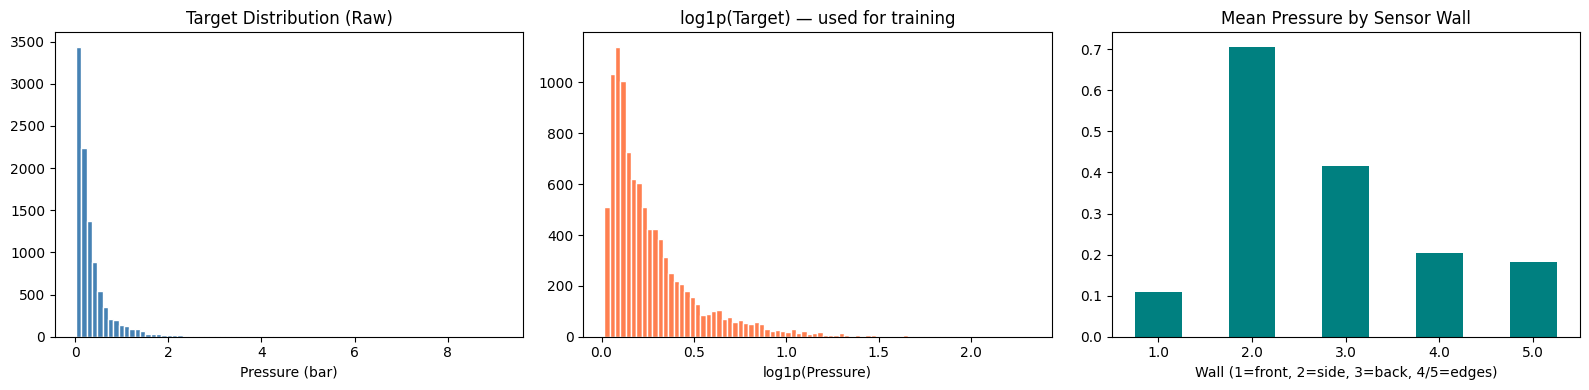

Side wall sensors (2) have ~6x higher pressure than front wall (1) — sensor position is dominant feature.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_raw[TARGET].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Target Distribution (Raw)'); axes[0].set_xlabel('Pressure (bar)')

axes[1].hist(np.log1p(train_raw[TARGET].dropna()), bins=80, color='coral', edgecolor='white')
axes[1].set_title('log1p(Target) — used for training'); axes[1].set_xlabel('log1p(Pressure)')

means = train_raw.groupby('Sensor Position Side')[TARGET].mean()
means.plot(kind='bar', ax=axes[2], color='teal', rot=0)
axes[2].set_title('Mean Pressure by Sensor Wall')
axes[2].set_xlabel('Wall (1=front, 2=side, 3=back, 4/5=edges)')

plt.tight_layout()
plt.show()
print('Side wall sensors (2) have ~6x higher pressure than front wall (1) — sensor position is dominant feature.')


## 5. Data Preprocessing

### 4.1 Data Cleaning

| Issue | Count | Fix |
|---|---|---|
| Status typos (9 variants) | ~7 rows | Map to 0/1 |
| Missing numeric values | 6–30 per column | Median imputation |
| Extreme pressure outliers (>50 bar in train, absent in test) | ~50 rows | Removed |
| Target outliers (>99.9th pct) | ~10 rows | Removed |
| Duplicate rows | variable | Removed |

### 4.2 Feature Engineering

Physics-informed features: tank energy, critical pressure ratio, sensor geometry, distance-decay, temperature difference, etc.


In [5]:
def feature_engineering(df):
    """Add physics-informed engineered features."""
    df = df.copy()

    # ── Tank geometry ──────────────────────────────────────────────────────
    df['Tank_Volume']         = df['Tank Width (m)'] * df['Tank Length (m)'] * df['Tank Height (m)']
    df['Width_Length_Ratio']  = df['Tank Width (m)']  / (df['Tank Length (m)']  + 1e-9)
    df['Height_Length_Ratio'] = df['Tank Height (m)'] / (df['Tank Length (m)']  + 1e-9)
    df['Vapour_Height_Ratio'] = df['Vapour Height (m)'] / (df['Tank Height (m)'] + 1e-9)
    df['Vapour_Volume']       = df['Tank Width (m)'] * df['Tank Length (m)'] * df['Vapour Height (m)']
    df['BLEVE_Height_Ratio']  = df['BLEVE Height (m)'] / (df['Tank Height (m)'] + 1e-9)

    # ── Energy / pressure features ─────────────────────────────────────────
    df['Tank_Energy']           = df['Tank Failure Pressure (bar)'] * df['Tank_Volume']
    df['Pressure_per_Volume']   = df['Tank Failure Pressure (bar)'] / (df['Tank_Volume'] + 1e-9)
    # NOTE: column is 'Liquid Ratio' after renaming (was 'Liquid Ratio (%)')
    df['Pressure_LiquidRatio']  = df['Tank Failure Pressure (bar)'] * df['Liquid Ratio']
    df['Pressure_VapTemp']      = df['Tank Failure Pressure (bar)'] * df['Vapour Temperature (K)']
    df['Critical_Ratio']        = df['Tank Failure Pressure (bar)'] / (df['Liquid Critical Pressure (bar)'] + 1e-9)
    df['log_Pressure']          = np.log1p(df['Tank Failure Pressure (bar)'])
    df['log_Distance']          = np.log1p(df['Obstacle Distance to BLEVE (m)'])

    # ── Temperature ────────────────────────────────────────────────────────
    df['Temp_Diff'] = df['Vapour Temperature (K)'] - df['Liquid Temperature (K)']
    # Superheat degree: how far above boiling (converted K from stored-K)
    df['Superheat_Degree'] = df['Vapour Temperature (K)'] - df['Liquid Boiling Temperature (K)']

    # ── Obstacle ───────────────────────────────────────────────────────────
    df['Obstacle_Volume']    = df['Obstacle Width (m)'] * df['Obstacle Height (m)'] * df['Obstacle Thickness (m)']
    df['Obstacle_H_W_Ratio'] = df['Obstacle Height (m)'] / (df['Obstacle Width (m)'] + 1e-9)

    # ── Sensor geometry ────────────────────────────────────────────────────
    df['Distance_to_Sensor'] = np.sqrt(df['Sensor Position x']**2
                                       + df['Sensor Position y']**2
                                       + df['Sensor Position z']**2)
    df['Sensor_z_norm']  = df['Sensor Position z'] / (df['Obstacle Height (m)'] + 1e-9)
    df['Sensor_x_norm']  = df['Sensor Position x'] / (df['Obstacle Distance to BLEVE (m)'] + 1e-9)
    df['Sensor_y_abs']   = np.abs(df['Sensor Position y'])
    df['Sensor_Angle']   = np.arctan2(df['Sensor Position y'], df['Sensor Position x'])

    # ── Inverse-square distance decay (key physics relationship) ──────────
    df['Inv_Dist_sq']    = 1.0 / (df['Distance_to_Sensor']**2 + 1e-9)
    df['Scaled_Pressure']= df['Tank_Energy'] * df['Inv_Dist_sq']

    # Replace inf values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df


def full_preprocess(train_df, test_df):
    """Full preprocessing pipeline returning numpy arrays ready for modelling."""
    # ── Separate target ────────────────────────────────────────────────────
    y = train_df[TARGET].copy()
    X = train_df.drop(columns=[TARGET])
    # Also drop ID (not predictive)
    X.drop(columns=['ID'], inplace=True, errors='ignore')
    test_ids = test_df['ID'].values
    test_df = test_df.drop(columns=['ID'], errors='ignore').reset_index(drop=True)

    mask = y.notna()
    X, y = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)

    # ── Feature engineering ───────────────────────────────────────────────
    X       = feature_engineering(X)
    test_df = feature_engineering(test_df)

    # ── Fix Status typos ──────────────────────────────────────────────────
    status_map = {'Superheated':1,'Superheat':1,'superheated':1,'Saperheated':1,
                  'Subcooled':0,'subcooled':0,'Subcool':0,'Subcoled':0}
    X['Status']       = X['Status'].map(status_map).fillna(0).astype(float)
    test_df['Status'] = test_df['Status'].map(status_map).fillna(0).astype(float)

    # ── One-hot encode Sensor Position Side ──────────────────────────────
    # Fill NaN in Side with mode before encoding
    side_mode = X['Sensor Position Side'].mode()[0]
    X['Sensor Position Side'].fillna(side_mode, inplace=True)
    test_df['Sensor Position Side'].fillna(side_mode, inplace=True)

    ohe      = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    side_all = pd.concat([X[['Sensor Position Side']], test_df[['Sensor Position Side']]])
    ohe.fit(side_all)
    Xohe = pd.DataFrame(ohe.transform(X[['Sensor Position Side']]),
                        columns=ohe.get_feature_names_out())
    Tohe = pd.DataFrame(ohe.transform(test_df[['Sensor Position Side']]),
                        columns=ohe.get_feature_names_out())
    X       = pd.concat([X.drop(columns=['Sensor Position Side']).reset_index(drop=True), Xohe], axis=1)
    test_df = pd.concat([test_df.drop(columns=['Sensor Position Side']).reset_index(drop=True), Tohe], axis=1)

    # ── Remove outliers (train only) ──────────────────────────────────────
    before = len(X)
    X['_y'] = y.values
    X = X.drop_duplicates(subset=[c for c in X.columns if c != '_y'])
    X = X[X['Tank Failure Pressure (bar)'] <= 50]   # test max is ~42 bar
    X = X[X['_y'] <= X['_y'].quantile(0.999)]        # extreme target outliers
    y = X['_y'].reset_index(drop=True)
    X = X.drop(columns=['_y']).reset_index(drop=True)
    print(f'[Cleaning] Removed {before - len(X)} rows → {len(X)} remain')

    # ── Align columns ─────────────────────────────────────────────────────
    test_df = test_df.reindex(columns=X.columns, fill_value=0)

    # ── Median imputation ─────────────────────────────────────────────────
    imp      = SimpleImputer(strategy='median')
    X_arr    = imp.fit_transform(X)
    test_arr = imp.transform(test_df)

    return X_arr, y.values, test_arr, list(X.columns), imp, test_ids


X_arr, y, test_arr, feature_names, imp, test_ids = full_preprocess(train_raw.copy(), test_raw.copy())
y_log = np.log1p(y)

# Scaled versions for ElasticNet, SVR, Neural Network
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_arr)
T_sc   = scaler.transform(test_arr)

print(f'Features: {X_arr.shape[1]}  |  Train: {X_arr.shape[0]}  |  Test: {test_arr.shape[0]}')
print(f'y range: {y.min():.3f} – {y.max():.3f}  |  mean: {y.mean():.4f}')


[Cleaning] Removed 110 rows → 9930 remain
Features: 51  |  Train: 9930  |  Test: 3203
y range: 0.016 – 5.314  |  mean: 0.3543


## 6. Cross-Validation Setup & Evaluation Helper
Define 5-fold KFold cross-validation and a reusable evaluation function
that computes MAPE, R², RMSE, and MAE for any model

In [6]:
kf = KFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)

def evaluate(y_true, y_pred, label=''):
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    if label:
        print(f'{label:40s}  MAPE={mape:.4f}  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return {'MAPE': mape, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

results = {}
print(f'{NFOLDS}-fold KFold CV configured.')


5-fold KFold CV configured.


## 7. Model 1 — ElasticNet (Linear Baseline)

ElasticNet combines L1 and L2 regularisation — it is a **linear model** and serves as our baseline.
As a linear model it can only capture linear relationships in the feature space.
Tune ElasticNet using RandomizedSearchCV (15 iterations, 3-fold CV).
Train with 5-fold CV, predicting on out-of-fold (OOF) samples.
Predictions are back-transformed from log-space using expm1.
ElasticNet serves as the interpretable linear baseline.


In [ ]:
# Define hyperparameter search space for ElasticNet
elastic_param_grid = {
    'alpha':    [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# RandomizedSearch over 15 random combinations using 3-fold CV
elastic_search = RandomizedSearchCV(
    ElasticNet(max_iter=5000, random_state=SEED),
    elastic_param_grid, n_iter=15, cv=3,
    scoring='neg_mean_absolute_percentage_error',
    random_state=SEED, n_jobs=-1
)
elastic_search.fit(X_sc, y_log)
BEST_ELASTIC = elastic_search.best_params_
print('Best ElasticNet params:', BEST_ELASTIC)

# Arrays to accumulate OOF predictions and averaged test predictions
elastic_oof  = np.zeros(len(y))
elastic_test = np.zeros(len(test_arr))
elastic_m    = []

for fold, (tr, val) in enumerate(kf.split(X_sc)):
    m = ElasticNet(**BEST_ELASTIC, max_iter=5000, random_state=SEED)
    m.fit(X_sc[tr], y_log[tr])
     # Back-transform log predictions and clip negatives to 0
    elastic_oof[val]  = np.expm1(m.predict(X_sc[val])).clip(0)
    elastic_test     += np.expm1(m.predict(T_sc)) / NFOLDS
    elastic_m.append(evaluate(y[val], elastic_oof[val], f'ElasticNet Fold {fold+1}'))
# Average metrics across all folds
elastic_mean = {k: float(np.mean([m[k] for m in elastic_m])) for k in ['MAPE','R2','RMSE','MAE']}
print(f'\nElasticNet Mean  →  MAPE={elastic_mean["MAPE"]:.4f}  R2={elastic_mean["R2"]:.4f}')
results['ElasticNet'] = elastic_mean


Best ElasticNet params: {'l1_ratio': 0.3, 'alpha': 0.05}
ElasticNet Fold 1                         MAPE=0.4517  R2=0.6129  RMSE=0.2651  MAE=0.1300
ElasticNet Fold 2                         MAPE=0.4585  R2=0.6599  RMSE=0.2616  MAE=0.1304
ElasticNet Fold 3                         MAPE=0.4675  R2=0.6038  RMSE=0.2992  MAE=0.1358
ElasticNet Fold 4                         MAPE=0.4534  R2=0.6640  RMSE=0.2591  MAE=0.1266
ElasticNet Fold 5                         MAPE=0.4787  R2=0.5966  RMSE=0.3109  MAE=0.1413

ElasticNet Mean  →  MAPE=0.4620  R2=0.6274


## 8. Model 2 — Support Vector Regression (SVR)

SVR uses kernel functions to map data into high-dimensional space — **fundamentally different** from linear and tree-based models.


In [ ]:
# Define hyperparameter search space for SVR
svr_param_grid = {
    'C':       [10, 50, 100, 200, 500],  # penalty for margin violations
    'gamma':   ['scale', 'auto', 0.01, 0.05, 0.1],# RBF kernel width
    'epsilon': [0.01, 0.05, 0.1, 0.2]    # epsilon-insensitive tube width
}
# RandomizedSearch over 15 random combinations using 3-fold CV
svr_search = RandomizedSearchCV(
    SVR(kernel='rbf'),
    svr_param_grid, n_iter=15, cv=3,
    scoring='neg_mean_absolute_percentage_error',
    random_state=SEED, n_jobs=-1
)
svr_search.fit(X_sc, y_log)
BEST_SVR = svr_search.best_params_
print('Best SVR params:', BEST_SVR)

# Arrays to accumulate OOF and averaged test predictions
svr_oof  = np.zeros(len(y))
svr_test = np.zeros(len(test_arr))
svr_m    = []

for fold, (tr, val) in enumerate(kf.split(X_sc)):
    m = SVR(kernel='rbf', **BEST_SVR)
    m.fit(X_sc[tr], y_log[tr])
     # Back-transform log predictions and clip negatives to 0
    svr_oof[val]  = np.expm1(m.predict(X_sc[val])).clip(0)
    svr_test     += np.expm1(m.predict(T_sc)) / NFOLDS# average test preds across folds
    svr_m.append(evaluate(y[val], svr_oof[val], f'SVR        Fold {fold+1}'))

# average metrics across all folds
svr_mean = {k: float(np.mean([m[k] for m in svr_m])) for k in ['MAPE','R2','RMSE','MAE']}
print(f'\nSVR Mean         →  MAPE={svr_mean["MAPE"]:.4f}  R2={svr_mean["R2"]:.4f}')
results['SVR'] = svr_mean


Best SVR params: {'gamma': 'scale', 'epsilon': 0.01, 'C': 10}
SVR        Fold 1                         MAPE=0.1372  R2=0.9734  RMSE=0.0695  MAE=0.0339
SVR        Fold 2                         MAPE=0.1387  R2=0.9777  RMSE=0.0670  MAE=0.0342
SVR        Fold 3                         MAPE=0.1417  R2=0.9742  RMSE=0.0763  MAE=0.0360
SVR        Fold 4                         MAPE=0.1387  R2=0.9831  RMSE=0.0581  MAE=0.0315
SVR        Fold 5                         MAPE=0.1416  R2=0.9676  RMSE=0.0881  MAE=0.0371

SVR Mean         →  MAPE=0.1396  R2=0.9752


## 9. Model 3 — XGBoost (Gradient Boosting)

XGBoost builds trees **sequentially**, each correcting previous errors — fundamentally different from linear and kernel-based models.
Hyperparameters tuned via RandomizedSearchCV with 3-fold CV.


In [ ]:
# Define hyperparameter search space for XGBoost
xgb_param_grid = {
    'n_estimators':     [800, 1000, 1200, 1500],
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.01, 0.03, 0.05, 0.08],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':        [0, 0.01, 0.1],
    'reg_lambda':       [1, 1.5, 2],
}
# RandomizedSearch over 25 random combinations using 3-fold CV (75 fits total)
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist',
                     random_state=SEED, verbosity=0),
    xgb_param_grid, n_iter=25, cv=3,
    scoring='neg_mean_absolute_percentage_error',# optimise for MAPE
    random_state=SEED, n_jobs=-1, verbose=1
)
xgb_search.fit(X_arr, y_log)
BEST_XGB = xgb_search.best_params_
print('Best XGB params:', BEST_XGB)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGB params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [ ]:
# Arrays to accumulate OOF and averaged test predictions
xgb_oof  = np.zeros(len(y))
xgb_test = np.zeros(len(test_arr))
xgb_m    = []

for fold, (tr, val) in enumerate(kf.split(X_arr)):
    m = xgb.XGBRegressor(
        **BEST_XGB, objective='reg:squarederror',
        tree_method='hist', random_state=SEED+fold,# different seed per fold for diversity
        verbosity=0, early_stopping_rounds=50 # stop if no improvement for 50 rounds
    )
    # Use validation fold as early stopping monitor
    m.fit(X_arr[tr], y_log[tr],
          eval_set=[(X_arr[val], y_log[val])],
          verbose=False)
     # Back-transform log predictions and clip negatives to 0
    xgb_oof[val]  = np.expm1(m.predict(X_arr[val])).clip(0)
    xgb_test     += np.expm1(m.predict(test_arr)) / NFOLDS# average test preds across folds
    xgb_m.append(evaluate(y[val], xgb_oof[val], f'XGBoost    Fold {fold+1}'))

# Average metrics across all folds
xgb_mean = {k: float(np.mean([m[k] for m in xgb_m])) for k in ['MAPE','R2','RMSE','MAE']}
print(f'\nXGBoost Mean     →  MAPE={xgb_mean["MAPE"]:.4f}  R2={xgb_mean["R2"]:.4f}')
results['XGBoost'] = xgb_mean


XGBoost    Fold 1                         MAPE=0.1186  R2=0.9664  RMSE=0.0781  MAE=0.0375
XGBoost    Fold 2                         MAPE=0.1189  R2=0.9675  RMSE=0.0809  MAE=0.0365
XGBoost    Fold 3                         MAPE=0.1243  R2=0.9647  RMSE=0.0894  MAE=0.0383
XGBoost    Fold 4                         MAPE=0.1167  R2=0.9711  RMSE=0.0760  MAE=0.0337
XGBoost    Fold 5                         MAPE=0.1211  R2=0.9694  RMSE=0.0857  MAE=0.0375

XGBoost Mean     →  MAPE=0.1199  R2=0.9678


## 10. Model 4 — Neural Network (MLP, PyTorch)

A deep MLP captures complex non-linear blast physics — **fundamentally different** from all previous models.  
Architecture: 4 hidden layers (512→256→128→64) with BatchNorm, GELU activations, dropout, and cosine LR scheduling.  
Early stopping with patience=40 prevents overfitting.


In [ ]:
class BleveNet(nn.Module):
    def __init__(self, n_in, dims=[512,256,128,64], dropout=0.2):
        super().__init__()
        layers, d = [], n_in
        for h in dims:
             # Each block: Linear → BatchNorm → GELU activation → Dropout
            layers += [nn.Linear(d,h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout)]
            d = h
         # Final output layer — single neuron for regression
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
         # Squeeze removes the extra dimension from output (batch_size, 1) → (batch_size,)
        return self.net(x).squeeze(1)

print(BleveNet(X_sc.shape[1]))


BleveNet(
  (net): Sequential(
    (0): Linear(in_features=51, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): GELU(approximate='none')
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
N_IN    = X_sc.shape[1]  # number of input features
nn_oof  = np.zeros(len(y))
nn_test = np.zeros(len(test_arr))
nn_m    = []

for fold, (tr, val) in enumerate(kf.split(X_sc)):
    torch.manual_seed(SEED + fold)  # different seed per fold for diversity
    model     = BleveNet(N_IN).to(DEVICE)
    opt       = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)  # decoupled weight decay
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=300)  # smooth LR decay
    criterion = nn.HuberLoss(delta=0.5)  # robust to large residuals vs pure MSE

    # Convert numpy arrays to PyTorch tensors and move to device
    Xtr_t = torch.tensor(X_sc[tr],  dtype=torch.float32).to(DEVICE)
    ytr_t = torch.tensor(y_log[tr], dtype=torch.float32).to(DEVICE)
    Xva_t = torch.tensor(X_sc[val], dtype=torch.float32).to(DEVICE)
    Xte_t = torch.tensor(T_sc,      dtype=torch.float32).to(DEVICE)

    # Mini-batch loader with shuffling for stochastic gradient descent
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=256, shuffle=True)

    best_mape, best_state, patience = float('inf'), None, 0

    for epoch in range(300):
        # Training loop
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
            opt.step()
        scheduler.step()

        # Validation evaluation
        model.eval()
        with torch.no_grad():
            vp = np.expm1(model(Xva_t).cpu().numpy()).clip(0)  # back-transform predictions
        vm = mean_absolute_percentage_error(y[val], vp)

        # Save best model state and reset patience counter
        if vm < best_mape:
            best_mape = vm; best_state = copy.deepcopy(model.state_dict()); patience = 0
        else:
            patience += 1
        if patience >= 40: break  # early stopping

    # Restore best model weights before generating final predictions
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        nn_oof[val]  = np.expm1(model(Xva_t).cpu().numpy()).clip(0)
        nn_test     += np.expm1(model(Xte_t).cpu().numpy()).clip(0) / NFOLDS  # average across folds

    mm = evaluate(y[val], nn_oof[val], f'NeuralNet  Fold {fold+1}')
    nn_m.append(mm)
    print(f'            → stopped ep={epoch+1}  best_val_mape={best_mape:.4f}')

# Average metrics across all folds
nn_mean = {k: float(np.mean([m[k] for m in nn_m])) for k in ['MAPE','R2','RMSE','MAE']}
print(f'\nNN Mean          →  MAPE={nn_mean["MAPE"]:.4f}  R2={nn_mean["R2"]:.4f}')
results['Neural Network'] = nn_mean


NeuralNet  Fold 1                         MAPE=0.1396  R2=0.9667  RMSE=0.0777  MAE=0.0392
            → stopped ep=300  best_val_mape=0.1396
NeuralNet  Fold 2                         MAPE=0.1320  R2=0.9724  RMSE=0.0745  MAE=0.0394
            → stopped ep=300  best_val_mape=0.1320
NeuralNet  Fold 3                         MAPE=0.1380  R2=0.9662  RMSE=0.0874  MAE=0.0420
            → stopped ep=300  best_val_mape=0.1380
NeuralNet  Fold 4                         MAPE=0.1352  R2=0.9732  RMSE=0.0732  MAE=0.0386
            → stopped ep=300  best_val_mape=0.1352
NeuralNet  Fold 5                         MAPE=0.1415  R2=0.9616  RMSE=0.0960  MAE=0.0426
            → stopped ep=300  best_val_mape=0.1415

NN Mean          →  MAPE=0.1373  R2=0.9680


## 11. Model Comparison
Summarise and visualise cross-validation results for all four models.
XGBoost and Neural Network are selected for the final ensemble based on
best MAPE scores and complementary error patterns.

=== 5-Fold Cross-Validation Results ===
                  MAPE      R2    RMSE     MAE
Model                                         
ElasticNet      0.4620  0.6274  0.2792  0.1328
SVR             0.1396  0.9752  0.0718  0.0346
XGBoost         0.1199  0.9678  0.0820  0.0367
Neural Network  0.1373  0.9680  0.0817  0.0404


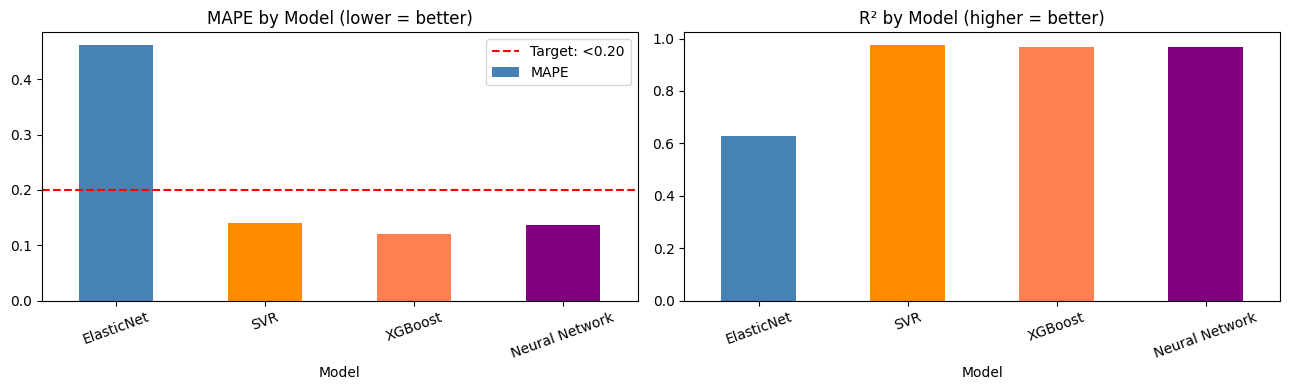


Conclusion:
- ElasticNet (linear) scores worst — blast physics are highly non-linear
- SVR captures non-linearities via RBF kernel but does not scale as well
- XGBoost and Neural Network perform best — selected for final ensemble


In [ ]:
# Compile all model results into a summary dataframe
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
print('=== 5-Fold Cross-Validation Results ===')
print(results_df.to_string())

# Visualise MAPE and R² side by side for all models
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['steelblue', 'darkorange', 'coral', 'purple']
results_df['MAPE'].plot(kind='bar', ax=axes[0], color=colors, rot=20)
axes[0].axhline(0.20, color='red', ls='--', label='Target: <0.20')  # mark the 0.20 threshold
axes[0].legend()
axes[0].set_title('MAPE by Model (lower = better)')
results_df['R2'].plot(kind='bar', ax=axes[1], color=colors, rot=20)
axes[1].set_title('R² by Model (higher = better)')
plt.tight_layout(); plt.show()

print('\nConclusion:')
print('- ElasticNet (linear) scores worst — blast physics are highly non-linear')
print('- SVR captures non-linearities via RBF kernel but does not scale as well')
print('- XGBoost and Neural Network perform best — selected for final ensemble')

## 12. Ensemble — XGBoost + Neural Network

We combine the two best models (XGBoost + Neural Network) using an **optimised weighted average**.
The optimal weight is found by minimising OOF MAPE — no test leakage.


Optimal weights  →  XGB: 0.65  NN: 0.35
Ensemble OOF MAPE: 0.1125


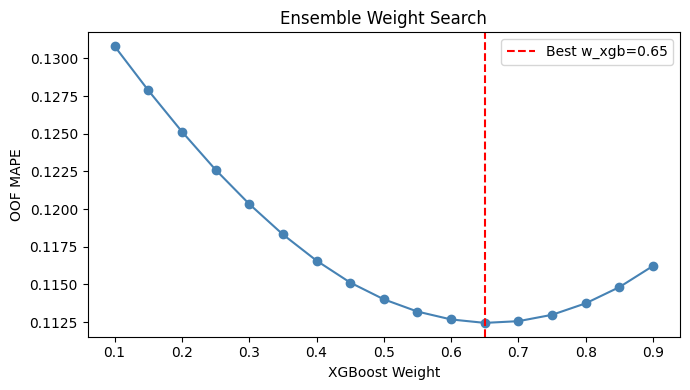

In [ ]:
# Grid search over 17 weights — evaluate OOF MAPE for each XGB/NN blend
weight_search = [
    (w, mean_absolute_percentage_error(y, w * xgb_oof + (1-w) * nn_oof))
    for w in np.linspace(0.1, 0.9, 17)
]

# Convert to dataframe and find the weight with lowest OOF MAPE
weight_df = pd.DataFrame(weight_search, columns=['w_xgb','MAPE'])
best_row  = weight_df.loc[weight_df['MAPE'].idxmin()]
W_XGB = float(best_row['w_xgb']); W_NN = 1.0 - W_XGB

print(f'Optimal weights  →  XGB: {W_XGB:.2f}  NN: {W_NN:.2f}')
print(f'Ensemble OOF MAPE: {best_row["MAPE"]:.4f}')

# Plot OOF MAPE vs XGBoost weight to visualise the search
plt.figure(figsize=(7,4))
plt.plot(weight_df['w_xgb'], weight_df['MAPE'], marker='o', color='steelblue')
plt.axvline(W_XGB, color='red', ls='--', label=f'Best w_xgb={W_XGB:.2f}')  # mark optimal weight
plt.xlabel('XGBoost Weight'); plt.ylabel('OOF MAPE')
plt.title('Ensemble Weight Search'); plt.legend(); plt.tight_layout(); plt.show()


Ensemble (XGB + NN)                       MAPE=0.1125  R2=0.9720  RMSE=0.0767  MAE=0.0349


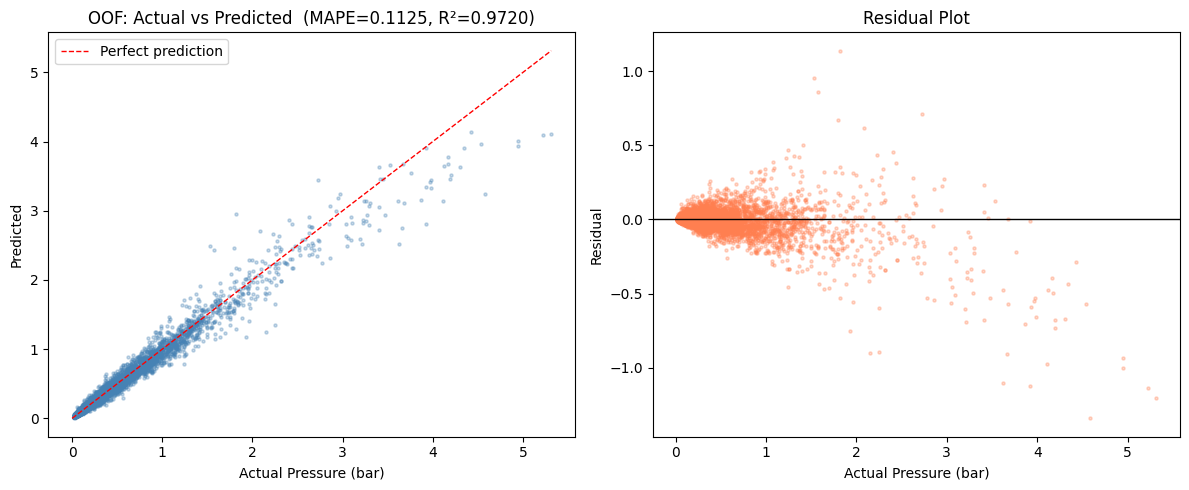

In [ ]:
# Combine OOF and test predictions using optimal ensemble weights
ensemble_oof  = W_XGB * xgb_oof  + W_NN * nn_oof
ensemble_test = W_XGB * xgb_test + W_NN * nn_test

# Clip test predictions to avoid extreme values outside training range
ensemble_test = np.clip(ensemble_test, y.min() * 0.5, y.max() * 1.5)

# Evaluate ensemble OOF performance
ens = evaluate(y, ensemble_oof, 'Ensemble (XGB + NN)           ')
results['Ensemble (XGB+NN)'] = ens

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted scatter — points should lie close to the red diagonal
axes[0].scatter(y, ensemble_oof, alpha=0.3, s=5, color='steelblue')
mx = max(y.max(), ensemble_oof.max())
axes[0].plot([0,mx],[0,mx],'r--',lw=1,label='Perfect prediction')
axes[0].set_xlabel('Actual Pressure (bar)'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'OOF: Actual vs Predicted  (MAPE={ens["MAPE"]:.4f}, R²={ens["R2"]:.4f})')
axes[0].legend()

# Residual plot — should show no systematic pattern if model is unbiased
axes[1].scatter(y, ensemble_oof - y, alpha=0.3, s=5, color='coral')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('Actual Pressure (bar)'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')
plt.tight_layout(); plt.show()

## 13. Final Results Table

In [ ]:
# Compile all models including ensemble into final comparison table
final_df = pd.DataFrame(results).T.round(4)
final_df.index.name = 'Model'
print('=== Complete Model Comparison — 5-Fold CV ===')
print(final_df.to_string())

# Identify best model by lowest MAPE
best = final_df['MAPE'].idxmin()
print(f'\n→ Best: {best}  MAPE={final_df.loc[best,"MAPE"]:.4f}  R²={final_df.loc[best,"R2"]:.4f}')


=== Complete Model Comparison — 5-Fold CV ===
                     MAPE      R2    RMSE     MAE
Model                                            
ElasticNet         0.4620  0.6274  0.2792  0.1328
SVR                0.1396  0.9752  0.0718  0.0346
XGBoost            0.1199  0.9678  0.0820  0.0367
Neural Network     0.1373  0.9680  0.0817  0.0404
Ensemble (XGB+NN)  0.1125  0.9720  0.0767  0.0349

→ Best: Ensemble (XGB+NN)  MAPE=0.1125  R²=0.9720


## 14. Feature Importance (XGBoost)
Train XGBoost on full training set and extract feature importances.
Confirms which engineered and raw features drive predictions most.

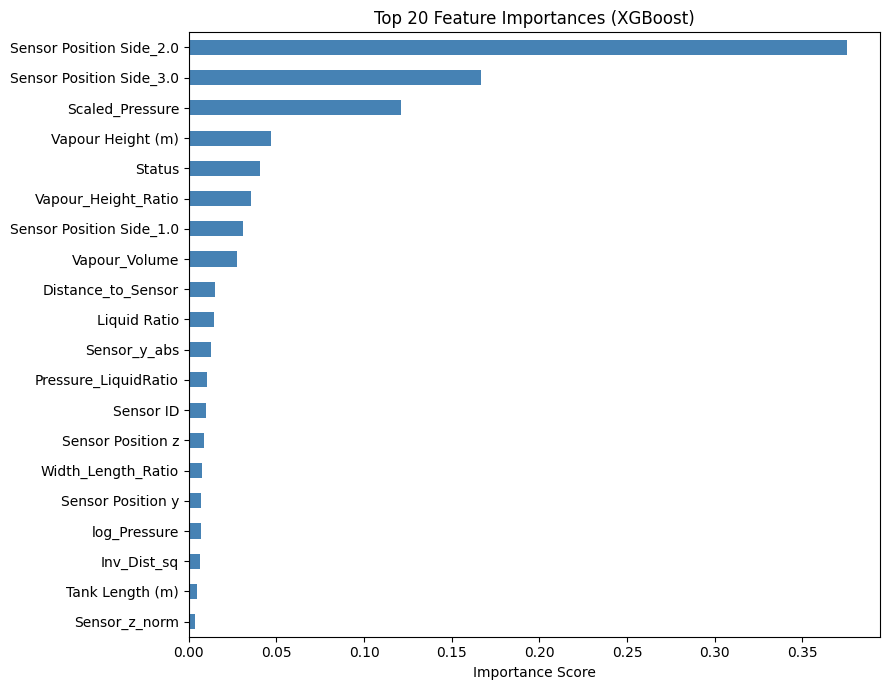

Top 10:
Sensor Position Side_2.0    0.3755
Sensor Position Side_3.0    0.1665
Scaled_Pressure             0.1211
Vapour Height (m)           0.0466
Status                      0.0408
Vapour_Height_Ratio         0.0354
Sensor Position Side_1.0    0.0306
Vapour_Volume               0.0276
Distance_to_Sensor          0.0152
Liquid Ratio                0.0141
dtype: float32


In [ ]:
# Train XGBoost on full training data to get stable feature importances
fi_model = xgb.XGBRegressor(**BEST_XGB, objective='reg:squarederror',
                              tree_method='hist', random_state=SEED, verbosity=0)
fi_model.fit(X_arr, y_log)

# Map importance scores to feature names and sort descending
fi = pd.Series(fi_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot top 20 features
plt.figure(figsize=(9, 7))
fi.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

# Print top 10 for quick reference
print('Top 10:'); print(fi.head(10).round(4))


## 15. Generate Submission File

In [18]:
# Use actual test IDs from the test CSV
submission = pd.DataFrame({
    'ID':   test_ids,
    TARGET: ensemble_test
})
submission.to_csv('prediction.csv', index=False)

print('✅ Saved prediction.csv')
print(f'Shape: {submission.shape}')
print(f'NaN: {submission.isnull().sum().sum()} | Negatives: {(submission[TARGET]<0).sum()}')
print(f'Mean: {submission[TARGET].mean():.4f} | Min: {submission[TARGET].min():.4f} | Max: {submission[TARGET].max():.4f}')
assert submission.shape[0] == 3203, f'Wrong row count: {submission.shape[0]}'
assert submission.isnull().sum().sum() == 0, 'NaNs found!'
print('\n✅ All checks passed. Submit prediction.csv to Kaggle.')
submission.head(10)


✅ Saved prediction.csv
Shape: (3203, 2)
NaN: 0 | Negatives: 0
Mean: 0.3300 | Min: 0.0152 | Max: 5.2098

✅ All checks passed. Submit prediction.csv to Kaggle.


,ID,Target Pressure (bar)
0,0,0.229975
1,1,0.248781
2,2,0.323282
3,3,0.290738
4,4,0.284558
5,5,0.249289
6,6,0.156262
7,7,0.166290
8,8,0.231541
9,9,2.006081
